In [2]:
import numpy as np
import matplotlib.pyplot as plt

from FixedPoint import FXnum, FXfamily

In [3]:
np.random.seed(0)

N = 200
t = np.arange(N)

# true signal
x_true = np.sin(0.1 * t)

# noisy measurement
z = x_true + np.random.normal(0, 0.1, N)

In [4]:
def kalman_float(z):
    x_est = 0
    P = 1

    Q = 0.01  # process noise
    R = 0.1   # measurement noise

    x_out = []

    for k in range(len(z)):
        # prediction
        x_pred = x_est
        P_pred = P + Q

        # update
        K = P_pred / (P_pred + R)
        x_est = x_pred + K * (z[k] - x_pred)
        P = (1 - K) * P_pred

        x_out.append(x_est)

    return np.array(x_out)

y_ref = kalman_float(z)

In [5]:
def kalman_float32(z):
    x_est = np.float32(0)
    P = np.float32(1)

    Q = np.float32(0.01)
    R = np.float32(0.1)

    x_out = []

    for k in range(len(z)):
        x_pred = x_est
        P_pred = P + Q

        K = P_pred / (P_pred + R)
        x_est = x_pred + K * (z[k] - x_pred)
        P = (1 - K) * P_pred

        x_out.append(x_est)

    return np.array(x_out)

y_f32 = kalman_float32(z)

In [6]:
fam_q8 = FXfamily(n_bits=8, n_intbits=4)
fam_q4 = FXfamily(n_bits=4, n_intbits=4)

In [7]:
def kalman_fixed(z, fam):
    x_est = FXnum(0, fam)
    P = FXnum(1, fam)

    Q = FXnum(0.01, fam)
    R = FXnum(0.1, fam)

    x_out = []

    for k in range(len(z)):
        x_pred = x_est
        P_pred = P + Q

        K = P_pred / (P_pred + R)

        z_fp = FXnum(z[k], fam)

        x_est = x_pred + K * (z_fp - x_pred)
        P = (FXnum(1, fam) - K) * P_pred

        x_out.append(float(x_est))

    return np.array(x_out)

y_q8 = kalman_fixed(z, fam_q8)
y_q4 = kalman_fixed(z, fam_q4)

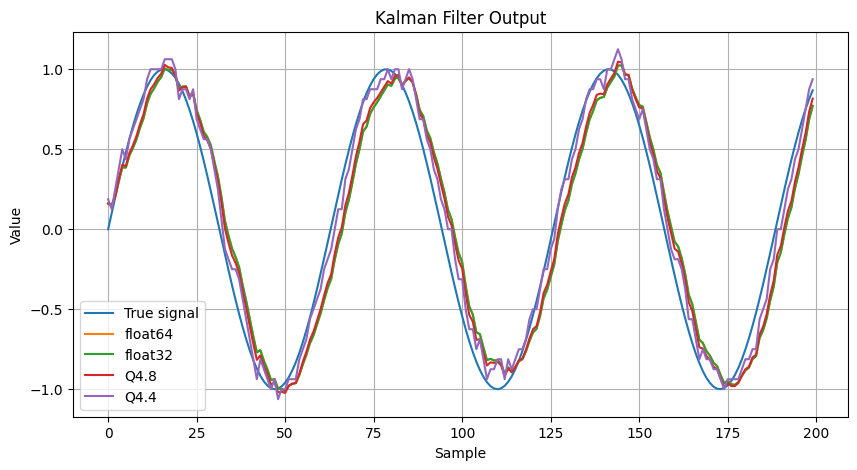

In [8]:
plt.figure(figsize=(10,5))

plt.plot(x_true, label="True signal")
plt.plot(y_ref, label="float64")
plt.plot(y_f32, label="float32")
plt.plot(y_q8, label="Q4.8")
plt.plot(y_q4, label="Q4.4")

plt.legend()
plt.title("Kalman Filter Output")
plt.xlabel("Sample")
plt.ylabel("Value")
plt.grid()
plt.show()

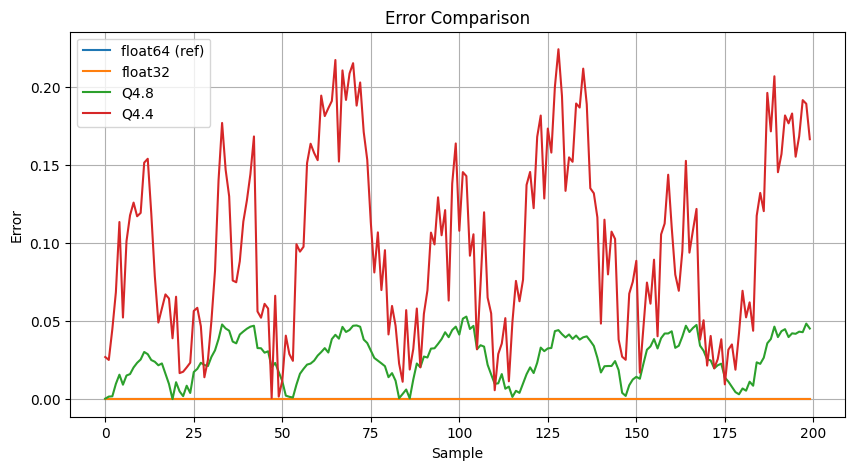

In [9]:
plt.figure(figsize=(10,5))

plt.plot(np.abs(y_ref - y_ref), label="float64 (ref)")
plt.plot(np.abs(y_ref - y_f32), label="float32")
plt.plot(np.abs(y_ref - y_q8), label="Q4.8")
plt.plot(np.abs(y_ref - y_q4), label="Q4.4")

plt.legend()
plt.title("Error Comparison")
plt.xlabel("Sample")
plt.ylabel("Error")
plt.grid()
plt.show()

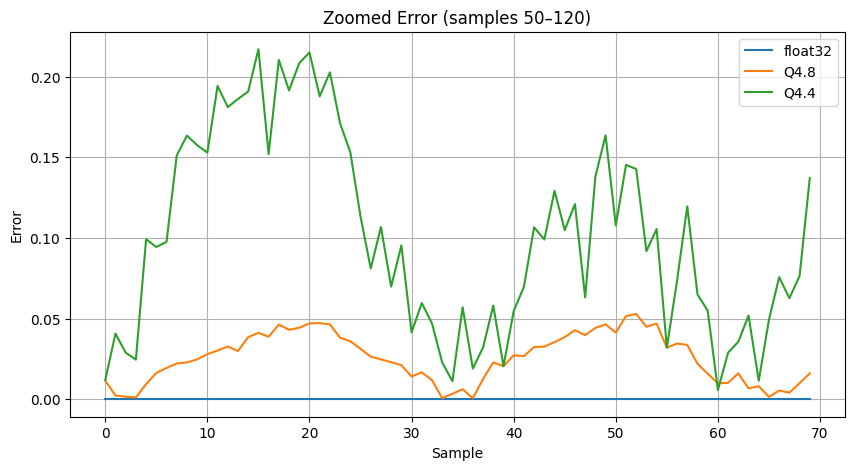

In [10]:
plt.figure(figsize=(10,5))

plt.plot(np.abs(y_ref - y_f32)[50:120], label="float32")
plt.plot(np.abs(y_ref - y_q8)[50:120], label="Q4.8")
plt.plot(np.abs(y_ref - y_q4)[50:120], label="Q4.4")

plt.legend()
plt.title("Zoomed Error (samples 50–120)")
plt.xlabel("Sample")
plt.ylabel("Error")
plt.grid()
plt.show()

In [11]:
def mse(y_true, y_test):
    return np.mean((y_true - y_test)**2)

mse_f64 = mse(y_ref, y_ref)      # sẽ = 0
mse_f32 = mse(y_ref, y_f32)
mse_q8  = mse(y_ref, y_q8)
mse_q4  = mse(y_ref, y_q4)

print(" MSE Results")
print(f"float64 (ref): {mse_f64:.6e}")
print(f"float32      : {mse_f32:.6e}")
print(f"Q4.8         : {mse_q8:.6e}")
print(f"Q4.4         : {mse_q4:.6e}")

 MSE Results
float64 (ref): 0.000000e+00
float32      : 4.547399e-17
Q4.8         : 9.084156e-04
Q4.4         : 1.314166e-02
